In [1]:
# Importando os pacotes que serão utilizados

# Para manipulação e tratamento dos dados
import numpy as np
import pandas as pd 
import time #utilizada para funções de tempo
import matplotlib.pyplot as plt #Utilizada para gráficos
import seaborn as sns #Utilizada para gráficos

# Modelo de churn baseado no comportamento de transições dos clientes 

In [2]:
df_original = pd.read_csv("abt_churn.csv")

# Exploração dos dados

As primeiras linhas do dataset.

In [ ]:
df_original.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


As últimas linhas do dataset.

In [ ]:
df_original.tail()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
5491,2025-02-01,ff07d926-f09e-420b-bebf-3dba02ae5dff,3,1,3.0,52,52,0,11.0,11.0,...,52,52,0,0.036148,0.085733,0.744779,0.098768,0.053507,0.0,0
5492,2025-03-01,ff07d926-f09e-420b-bebf-3dba02ae5dff,5,2,2.5,54,54,0,1.0,39.0,...,2,2,0,0.061868,0.173459,0.626703,0.104061,0.057551,0.0,1
5493,2024-06-01,ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15,3,5.0,162,162,0,17.0,19.0,...,162,162,0,0.219349,0.364253,1.083858,0.386839,0.252187,0.0,1
5494,2025-03-01,ff2cabd3-3316-4b3f-8494-c25f95e90524,8,1,8.0,57,57,0,19.0,19.0,...,57,57,0,0.098988,0.086730,2.005448,0.109843,0.060749,0.0,1
5495,2024-06-01,ff4909ad-4e52-4767-a6fc-0fbd76e37857,1,1,1.0,50,50,0,24.0,24.0,...,50,50,0,0.014623,0.121418,0.216772,0.119395,0.077835,0.0,1


Os tipos de dados e a contagem de valores não nulos de cada coluna.

In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5496 entries, 0 to 5495
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dtRef                       5496 non-null   object 
 1   idUsuario                   5496 non-null   object 
 2   qtdeTransacoes              5496 non-null   int64  
 3   qtdeDias                    5496 non-null   int64  
 4   mediaTransacoesDias         5496 non-null   float64
 5   saldoPontos                 5496 non-null   int64  
 6   qtdePontosPos               5496 non-null   int64  
 7   qtdePontosNeg               5496 non-null   int64  
 8   qtdeDiasUltimaTransacao     5496 non-null   float64
 9   qtdeDiasPrimeiraTransacao   5496 non-null   float64
 10  qtdSkuDistintos             5496 non-null   int64  
 11  qtdeChatMessage             5496 non-null   int64  
 12  qtdePresença                5496 non-null   int64  
 13  qtdeTrocaStreamElements     5496 

O percentual de valores ausentes em cada coluna.

In [ ]:
df_original.isnull().sum() * 100 / len(df_original)

dtRef                         0.0
idUsuario                     0.0
qtdeTransacoes                0.0
qtdeDias                      0.0
mediaTransacoesDias           0.0
saldoPontos                   0.0
qtdePontosPos                 0.0
qtdePontosNeg                 0.0
qtdeDiasUltimaTransacao       0.0
qtdeDiasPrimeiraTransacao     0.0
qtdSkuDistintos               0.0
qtdeChatMessage               0.0
qtdePresença                  0.0
qtdeTrocaStreamElements       0.0
qtdeChurn                     0.0
qtdePonei                     0.0
qtdeAirflowLover              0.0
qtdePresencaStreak            0.0
qtdeDailyLoot                 0.0
qtdeRLover                    0.0
qtdeVendaItemRPG              0.0
qtdeTransacoesD7              0.0
qtdeDiasD7                    0.0
saldoPontosD7                 0.0
qtdePontosPosD7               0.0
qtdePontosNegD7               0.0
qtdeTransacoesD14             0.0
qtdeDiasD14                   0.0
saldoPontosD14                0.0
qtdePontosPosD

Total de duplicados

In [ ]:
df_original.duplicated().sum()

0

Verificando valores únicos

In [ ]:

df_original.nunique()

dtRef                           14
idUsuario                     2251
qtdeTransacoes                 759
qtdeDias                       217
mediaTransacoesDias           1941
saldoPontos                   1956
qtdePontosPos                 2270
qtdePontosNeg                  151
qtdeDiasUltimaTransacao         27
qtdeDiasPrimeiraTransacao      377
qtdSkuDistintos                 16
qtdeChatMessage                682
qtdePresença                   200
qtdeTrocaStreamElements         40
qtdeChurn                      106
qtdePonei                       34
qtdeAirflowLover                10
qtdePresencaStreak              42
qtdeDailyLoot                   27
qtdeRLover                       6
qtdeVendaItemRPG                19
qtdeTransacoesD7               152
qtdeDiasD7                       8
saldoPontosD7                  561
qtdePontosPosD7                504
qtdePontosNegD7                 16
qtdeTransacoesD14              209
qtdeDiasD14                     15
saldoPontosD14      

# Profile Report

Utilizando o Profile Report para reazilar a exploração inicial dos dados

In [ ]:
#from ydata_profiling import ProfileReport

#profile = ProfileReport(df_original)

#profile.to_file("previsao_churn.html")

Identifica as colunas numéricas, para usar nos boxplots a seguir.

In [ ]:
# Carregar variaveis para plot
# Pegaremos a partir da variavel 1 porque o ID_CLIENTE não iremos utilizar
variaveis_numericas = []
for i in df_original.columns[1:24].tolist():
        if df_original.dtypes[i] == 'int64' or df_original.dtypes[i] == 'float64':            
            print(i, ':' , df_original.dtypes[i]) 
            variaveis_numericas.append(i)    

qtdeTransacoes : int64
qtdeDias : int64
mediaTransacoesDias : float64
saldoPontos : int64
qtdePontosPos : int64
qtdePontosNeg : int64
qtdeDiasUltimaTransacao : float64
qtdeDiasPrimeiraTransacao : float64
qtdSkuDistintos : int64
qtdeChatMessage : int64
qtdePresença : int64
qtdeTrocaStreamElements : int64
qtdeChurn : int64
qtdePonei : int64
qtdeAirflowLover : int64
qtdePresencaStreak : int64
qtdeDailyLoot : int64
qtdeRLover : int64
qtdeVendaItemRPG : int64
qtdeTransacoesD7 : int64
qtdeDiasD7 : int64
saldoPontosD7 : int64


Quantas colunas numéricas foram encontradas.

In [ ]:
len(variaveis_numericas)

22

Plota um boxplot para cada variável numérica, para visualizar outliers.

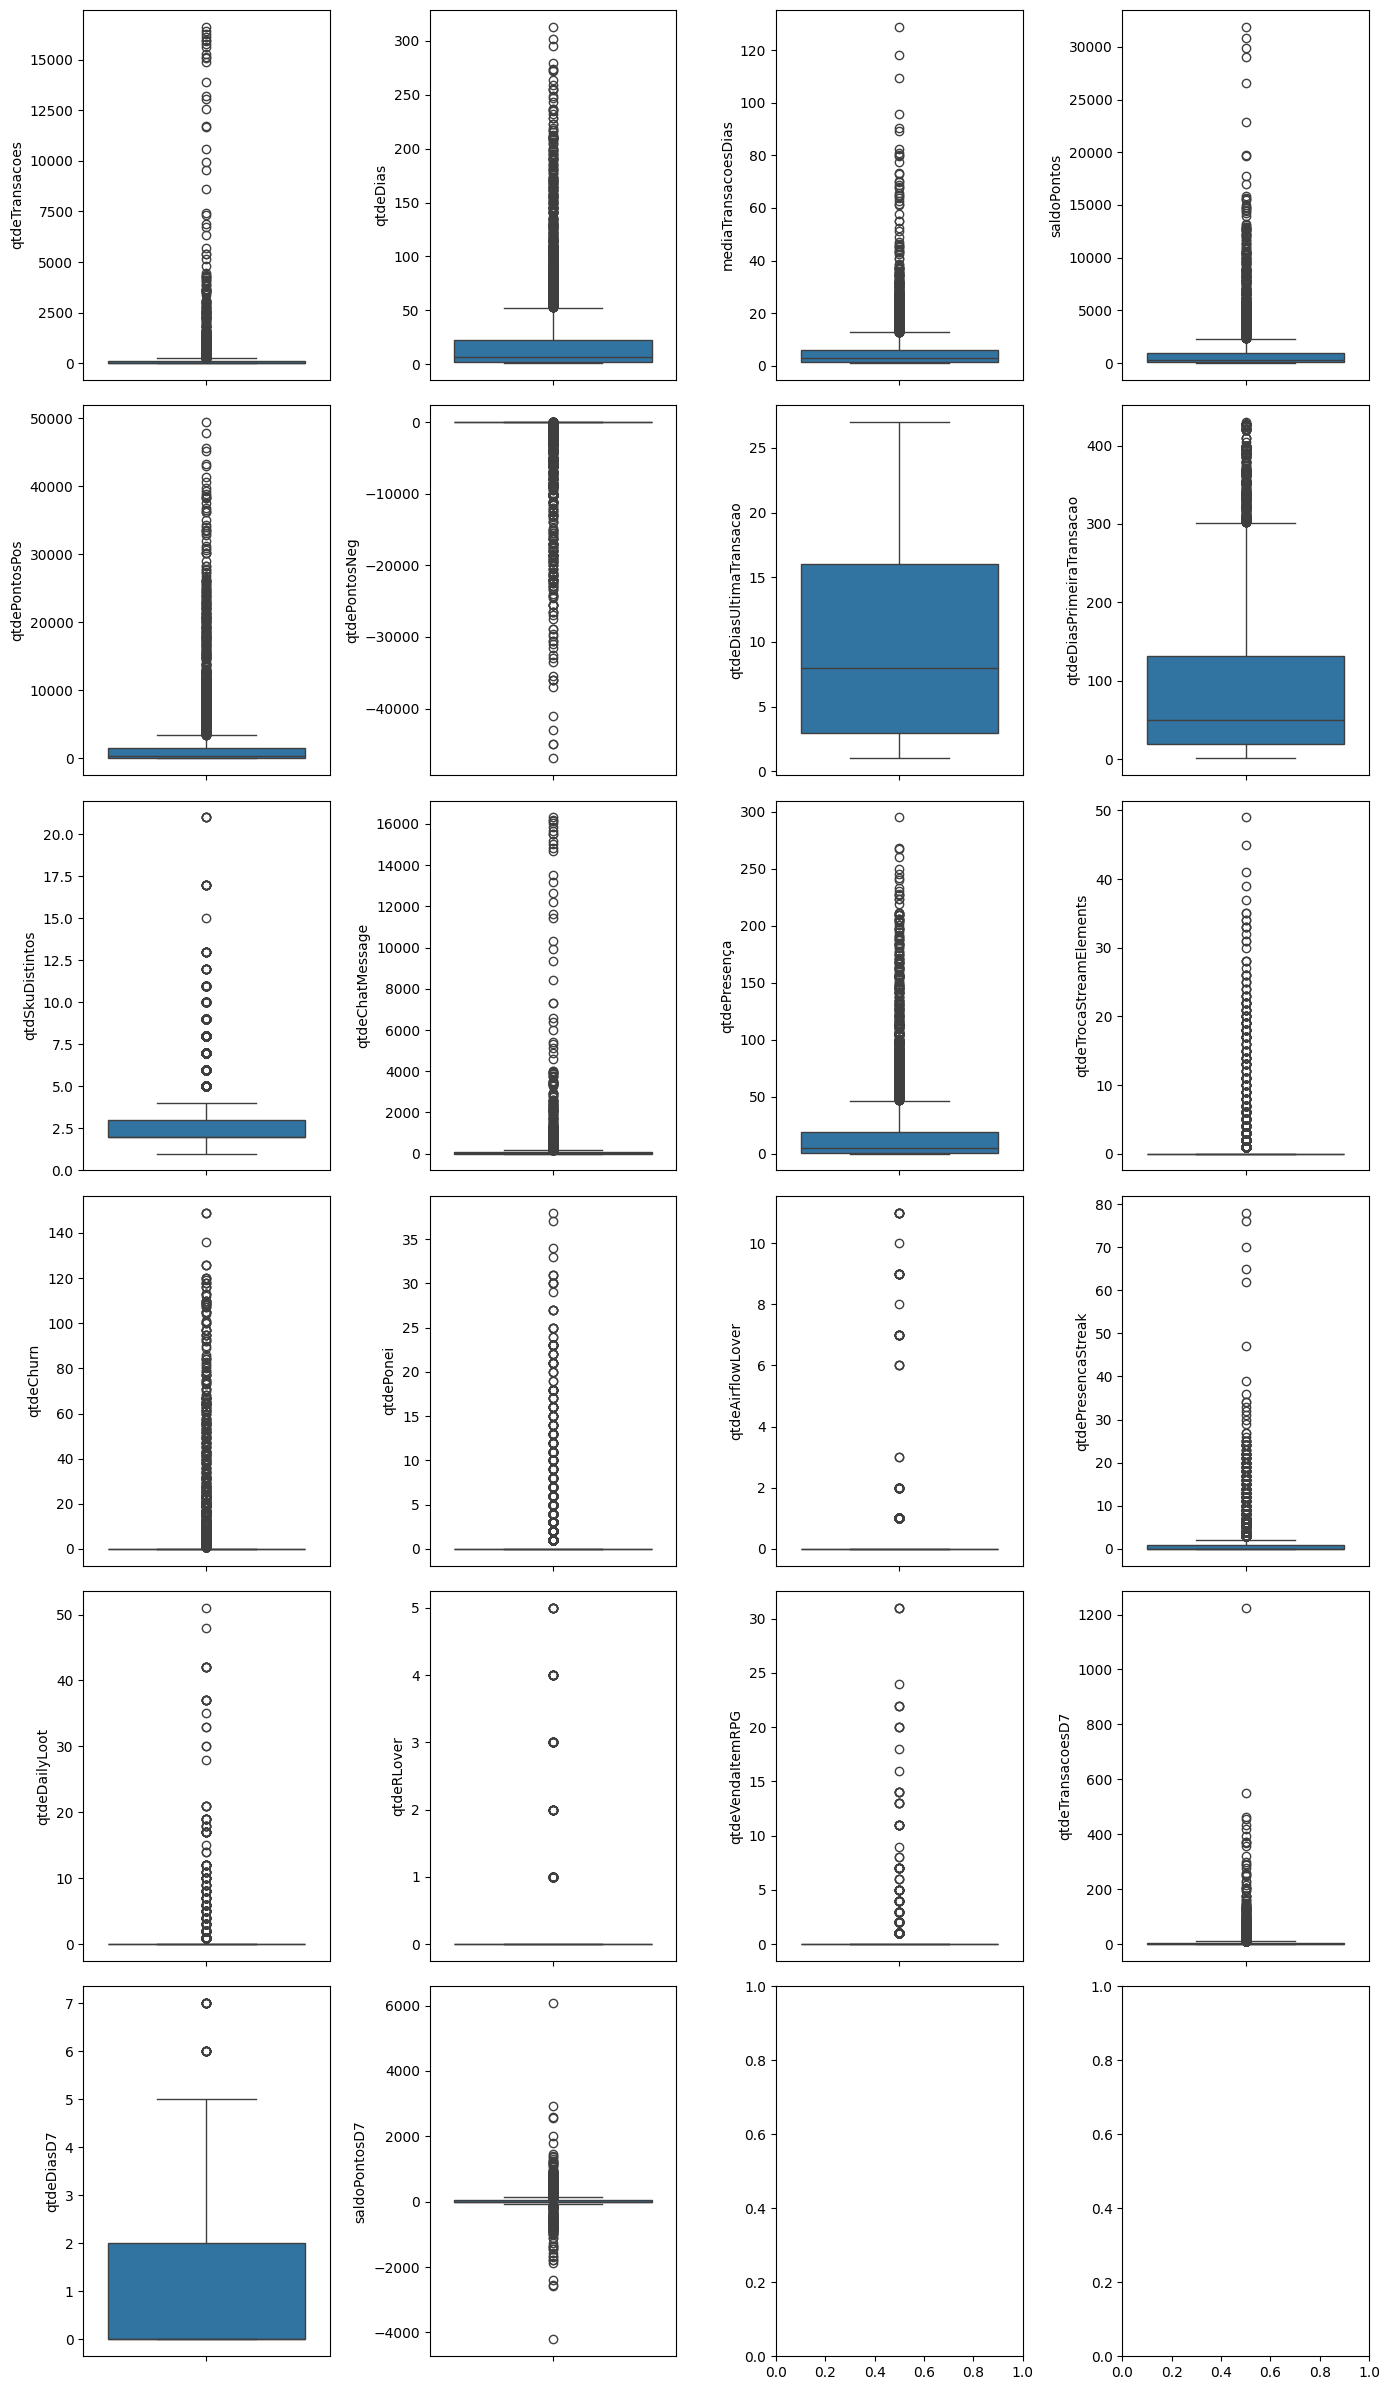

In [ ]:
#Podemos observar nos boxplots abaixo que algumas variáveis númericas apresentam uma grande quantidade de "possíveis" outliers
#Precisamos avaliar cada uma dessas variaveis dentro do contexto dos dados para saber se realmente iremos trata-las como outlier
%matplotlib inline
plt.rcParams["figure.figsize"] = [14.00, 24.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(6, 4) #6 linhas e 4 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.boxplot(data = df_original, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 4:
        linha += 1
        coluna = 0            

plt.show()

# MAPA DE CALOR DE CORRELAÇÃO

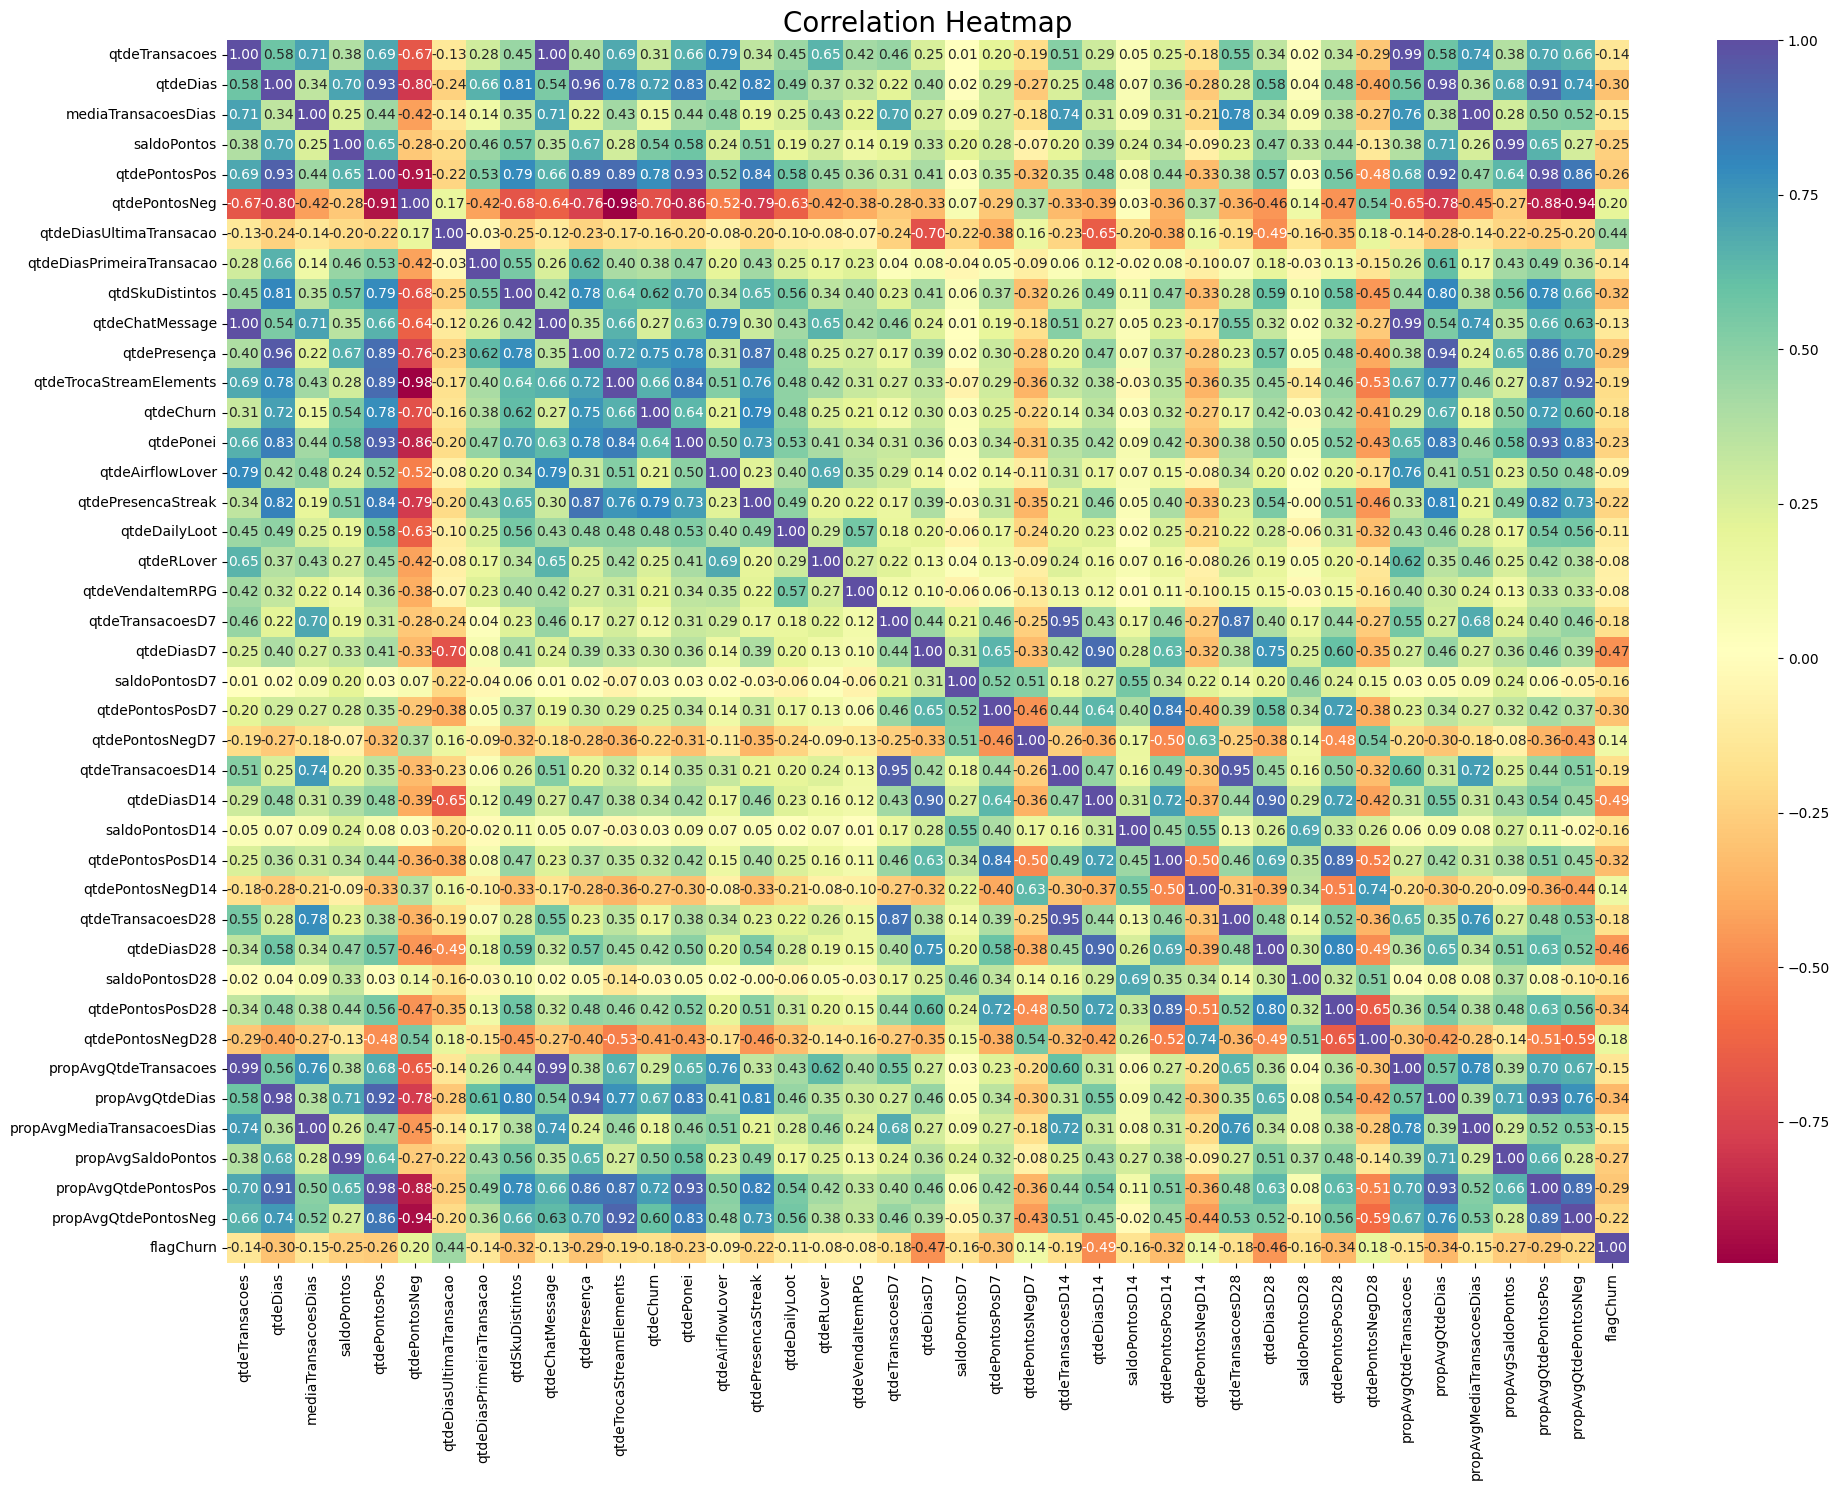

In [13]:
# Select only numeric columns
numeric_df = df_original.select_dtypes(include=np.number)

plt.figure(figsize=(20,15))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# Treinamento dos modelos 

In [14]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import RocCurveDisplay
from sklearn.decomposition import PCA

In [15]:
target_column = "flagChurn"

print("\n")
print("="*70)
print("TARGET COLUMN")
print("="*70)

print(target_column)

print("\nTarget Value Counts")
print(df_original[target_column].value_counts())



TARGET COLUMN
flagChurn

Target Value Counts
flagChurn
0    2908
1    2588
Name: count, dtype: int64


In [16]:
leakage_columns = [
    "flagChurn",
    "dtRef",
    "idUsuario" ,
    "qtdeRLover",
    "qtdeAirflowLover",
    "qtdePontosNegD14",
    "qtdePontosNegD7"
]

X = df_original.drop(columns=leakage_columns)



y = df_original[target_column]

In [17]:
# ============================================================
# CHECAGEM DE VAZAMENTO: qtdeChurn
# ============================================================
# 'qtdeChurn' ficou fora da lista de leakage_columns, mas o nome sugere
# contagem de eventos de churn passados -- vale confirmar que a coluna
# nao vaza o target antes de confiar no modelo.

corr_qtdeChurn = df_original[['qtdeChurn', target_column]].corr().iloc[0, 1]

print(f"Correlacao entre qtdeChurn e {target_column}: {corr_qtdeChurn:.4f}")
print()
print("Se a correlacao for muito alta (ex.: > 0.7-0.8), 'qtdeChurn' provavelmente")
print("deveria entrar na lista de leakage_columns junto com o restante.")
print("Se for baixa, e razoavel manter -- mas vale checar a definicao exata")
print("da coluna (ela e calculada so com dados ANTERIORES ao periodo de")
print("referencia, ou pode incluir o proprio evento que estamos prevendo?).")


Correlacao entre qtdeChurn e flagChurn: -0.1803

Se a correlacao for muito alta (ex.: > 0.7-0.8), 'qtdeChurn' provavelmente
deveria entrar na lista de leakage_columns junto com o restante.
Se for baixa, e razoavel manter -- mas vale checar a definicao exata
da coluna (ela e calculada so com dados ANTERIORES ao periodo de
referencia, ou pode incluir o proprio evento que estamos prevendo?).


In [18]:
# ============================================================
# IDENTIFICAR COLUNAS CATEGÓRICAS E NUMÉRICAS
# ============================================================

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("\n")
print("="*70)
print("CATEGORICAL COLUMNS")
print("="*70)

print(categorical_columns, len(categorical_columns))

print("\n")
print("="*70)
print("NUMERICAL COLUMNS")
print("="*70)

print(numerical_columns, len(numerical_columns))



CATEGORICAL COLUMNS
[] 0


NUMERICAL COLUMNS
['qtdeTransacoes', 'qtdeDias', 'mediaTransacoesDias', 'saldoPontos', 'qtdePontosPos', 'qtdePontosNeg', 'qtdeDiasUltimaTransacao', 'qtdeDiasPrimeiraTransacao', 'qtdSkuDistintos', 'qtdeChatMessage', 'qtdePresença', 'qtdeTrocaStreamElements', 'qtdeChurn', 'qtdePonei', 'qtdePresencaStreak', 'qtdeDailyLoot', 'qtdeVendaItemRPG', 'qtdeTransacoesD7', 'qtdeDiasD7', 'saldoPontosD7', 'qtdePontosPosD7', 'qtdeTransacoesD14', 'qtdeDiasD14', 'saldoPontosD14', 'qtdePontosPosD14', 'qtdeTransacoesD28', 'qtdeDiasD28', 'saldoPontosD28', 'qtdePontosPosD28', 'qtdePontosNegD28', 'propAvgQtdeTransacoes', 'propAvgQtdeDias', 'propAvgMediaTransacoesDias', 'propAvgSaldoPontos', 'propAvgQtdePontosPos', 'propAvgQtdePontosNeg'] 36


In [19]:
# ============================================================
# TIME-BASED TRAIN/TEST SPLIT
# ============================================================

datas_ordenadas = sorted(df_original['dtRef'].unique())
n_meses_teste = max(1, round(len(datas_ordenadas) * 0.25))
corte = datas_ordenadas[-n_meses_teste]

mask_teste = df_original['dtRef'] >= corte
mask_treino = ~mask_teste

X_train, X_test = X[mask_treino], X[mask_teste]
y_train, y_test = y[mask_treino], y[mask_teste]

print("\n")
print("="*70)
print("TIME-BASED TRAIN/TEST SPLIT")
print("="*70)

print(f"Meses de treino ({len(datas_ordenadas) - n_meses_teste}): {datas_ordenadas[:-n_meses_teste]}")
print(f"Meses de teste  ({n_meses_teste}): {datas_ordenadas[-n_meses_teste:]}")

print("\nX_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

print("\nDistribuicao do target no treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuicao do target no teste:")
print(y_test.value_counts(normalize=True))

# Nota: se a distribuicao do target variar muito entre treino e teste,




TIME-BASED TRAIN/TEST SPLIT
Meses de treino (10): ['2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01']
Meses de teste  (4): ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01']

X_train Shape : (4174, 36)
X_test Shape  : (1322, 36)
y_train Shape : (4174,)
y_test Shape  : (1322,)

Distribuicao do target no treino:
flagChurn
0    0.540489
1    0.459511
Name: proportion, dtype: float64

Distribuicao do target no teste:
flagChurn
1    0.506808
0    0.493192
Name: proportion, dtype: float64


In [20]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Pipelines
preprocessor = ColumnTransformer(transformers=[

    ('num', numerical_transformer, numerical_columns),

    ('cat', categorical_transformer, categorical_columns)

])



LOGISTIC REGRESSION

Cross-Validation Scores : [0.7584, 0.7632, 0.7201, 0.7608, 0.7386, 0.7794, 0.7290, 0.6954, 0.7530, 0.7650]
Media                   : 0.7463
Desvio padrao           : 0.0240

Accuracy Score : 0.7368


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.67      0.71       652
           1       0.71      0.80      0.76       670

    accuracy                           0.74      1322
   macro avg       0.74      0.74      0.74      1322
weighted avg       0.74      0.74      0.74      1322



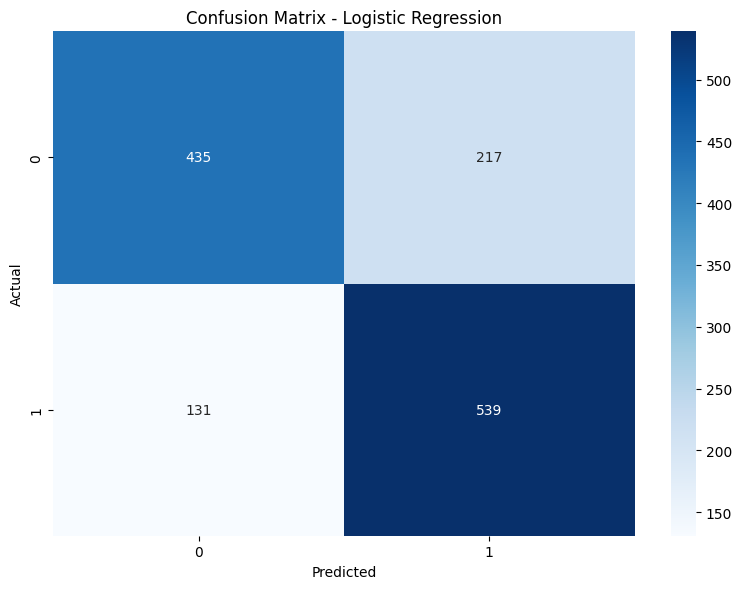

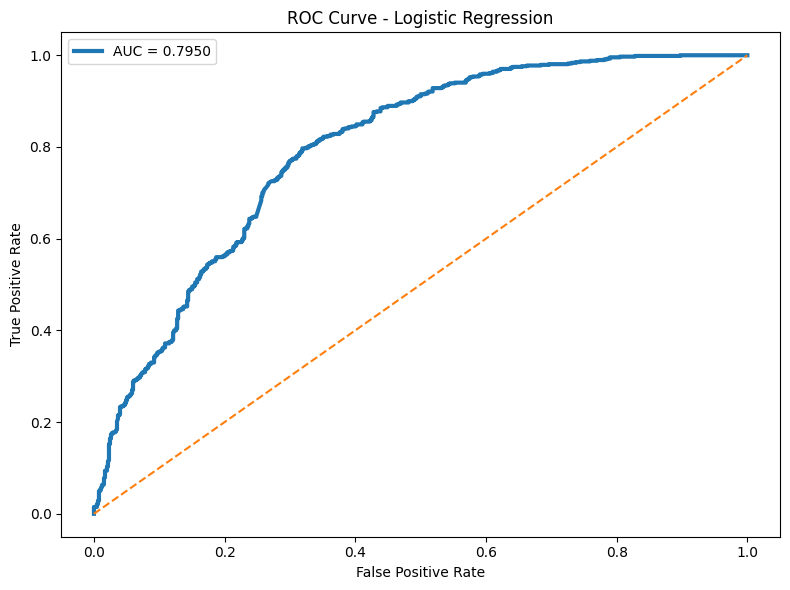



NAIVE BAYES

Cross-Validation Scores : [0.6100, 0.6459, 0.6435, 0.6603, 0.6403, 0.7146, 0.6523, 0.5899, 0.6163, 0.6619]
Media                   : 0.6435
Desvio padrao           : 0.0324

Accuracy Score : 0.6906


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.61      0.66       652
           1       0.67      0.77      0.71       670

    accuracy                           0.69      1322
   macro avg       0.69      0.69      0.69      1322
weighted avg       0.69      0.69      0.69      1322



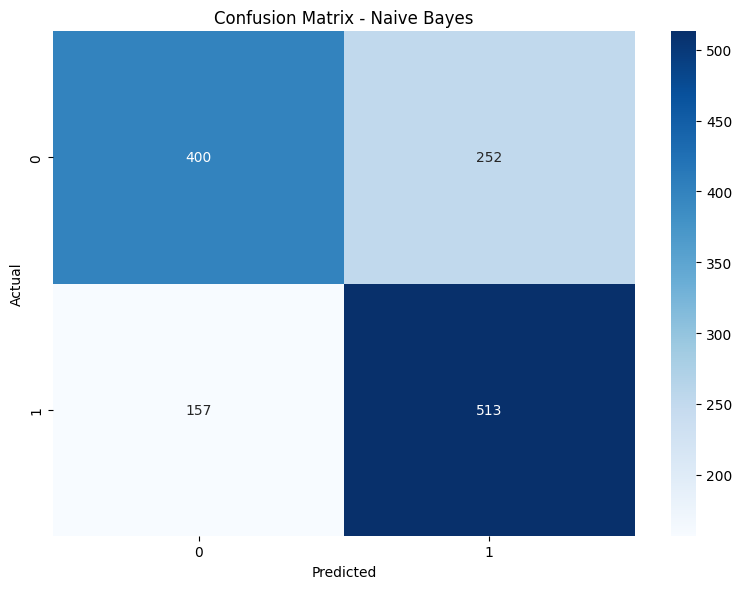

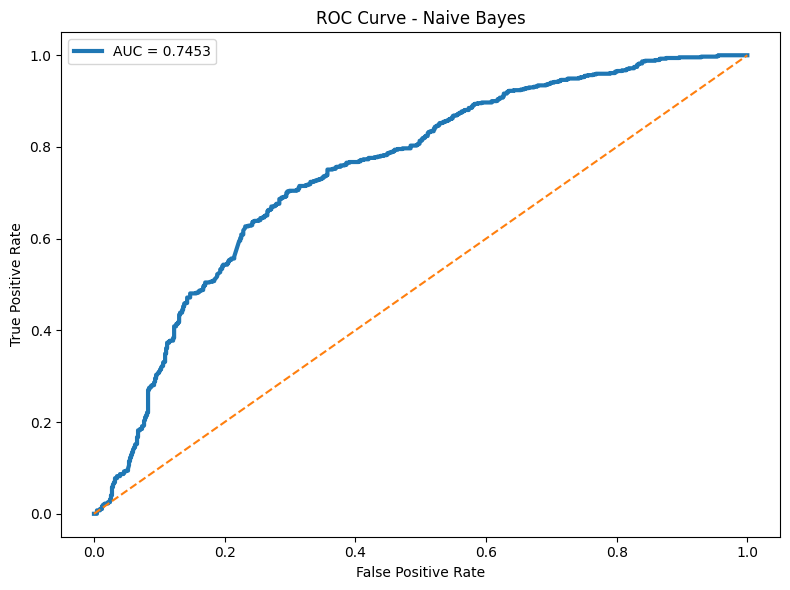



DECISION TREE

Cross-Validation Scores : [0.6651, 0.6579, 0.6794, 0.7010, 0.6643, 0.7242, 0.6859, 0.6547, 0.6954, 0.7050]
Media                   : 0.6833
Desvio padrao           : 0.0219

Accuracy Score : 0.6293


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.63      0.62      0.62       652
           1       0.63      0.64      0.64       670

    accuracy                           0.63      1322
   macro avg       0.63      0.63      0.63      1322
weighted avg       0.63      0.63      0.63      1322



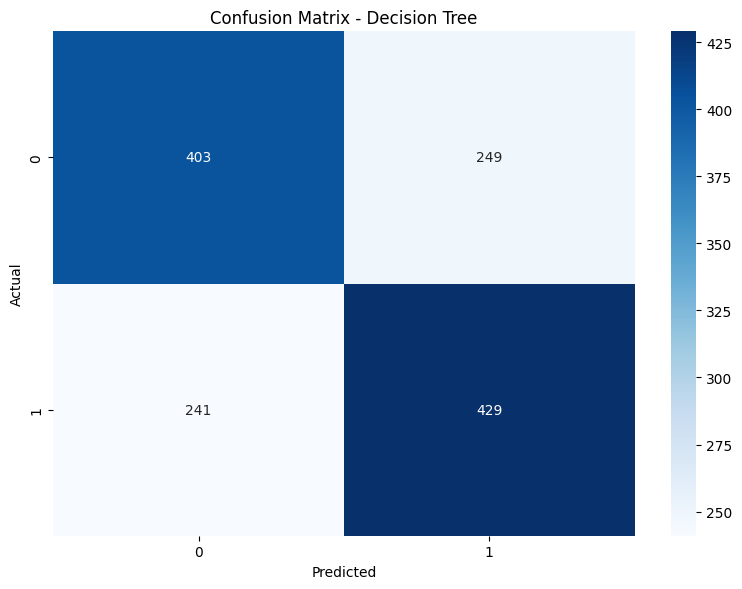

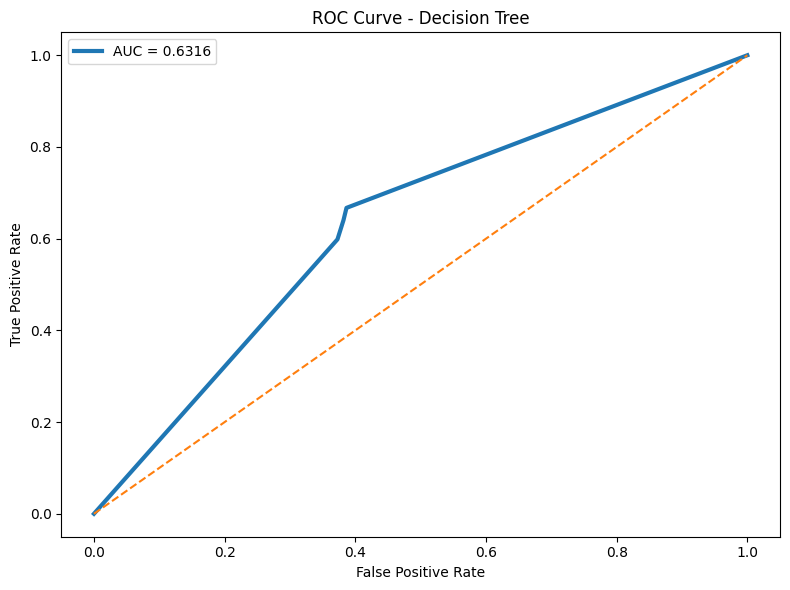



RANDOM FOREST

Cross-Validation Scores : [0.7153, 0.7177, 0.6962, 0.7201, 0.6954, 0.7602, 0.7050, 0.6930, 0.7146, 0.7770]
Media                   : 0.7195
Desvio padrao           : 0.0265

Accuracy Score : 0.6853


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.60      0.65       652
           1       0.66      0.77      0.71       670

    accuracy                           0.69      1322
   macro avg       0.69      0.68      0.68      1322
weighted avg       0.69      0.69      0.68      1322



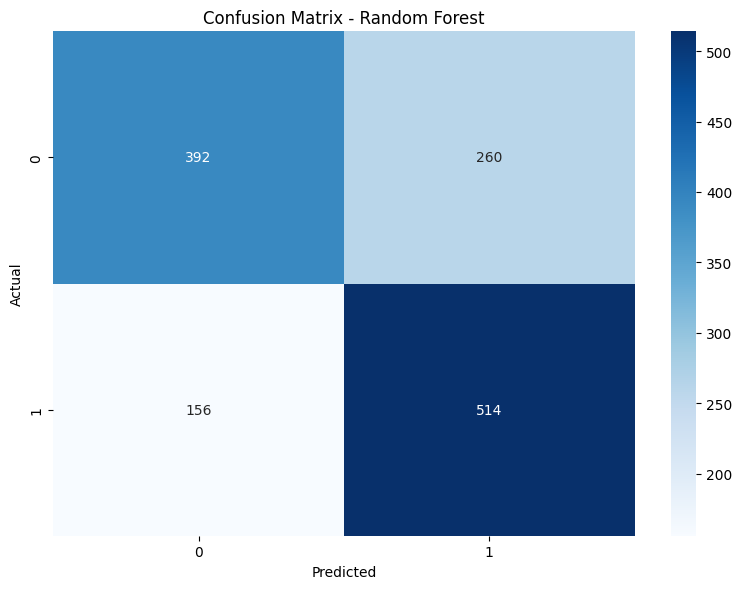

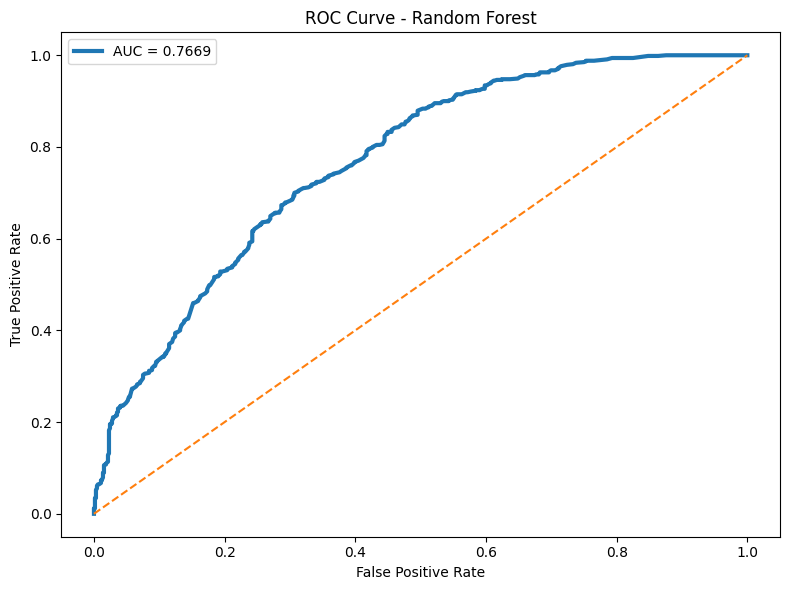



GRADIENT BOOSTING

Cross-Validation Scores : [0.7464, 0.7512, 0.7273, 0.7536, 0.7170, 0.7794, 0.7314, 0.7002, 0.7506, 0.7722]
Media                   : 0.7429
Desvio padrao           : 0.0230

Accuracy Score : 0.7110


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.59      0.67       652
           1       0.68      0.83      0.74       670

    accuracy                           0.71      1322
   macro avg       0.72      0.71      0.71      1322
weighted avg       0.72      0.71      0.71      1322



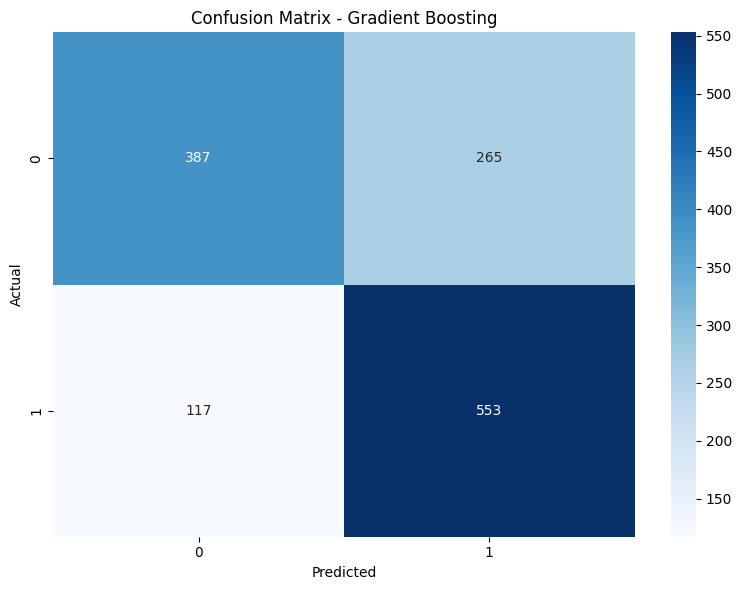

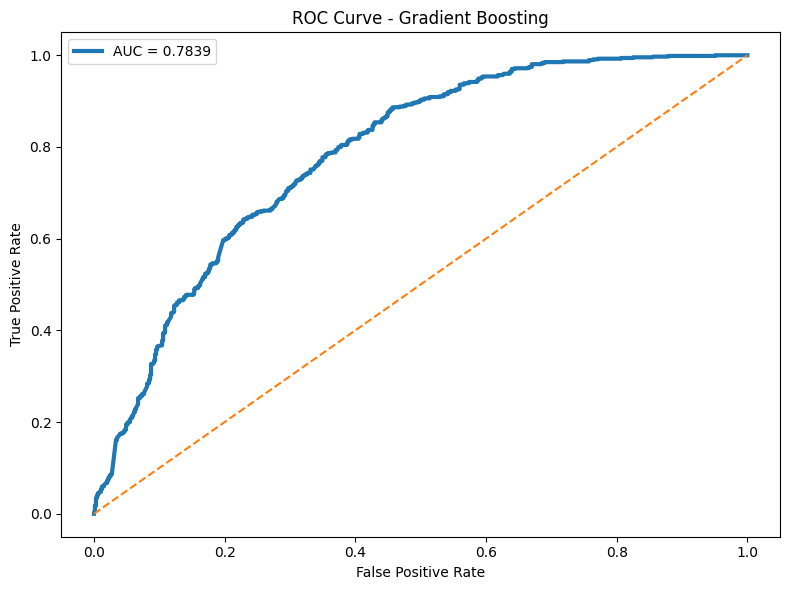



KNN

Cross-Validation Scores : [0.7153, 0.7129, 0.7225, 0.7416, 0.7122, 0.7458, 0.7002, 0.6978, 0.6978, 0.7458]
Media                   : 0.7192
Desvio padrao           : 0.0182

Accuracy Score : 0.7005


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       652
           1       0.69      0.74      0.72       670

    accuracy                           0.70      1322
   macro avg       0.70      0.70      0.70      1322
weighted avg       0.70      0.70      0.70      1322



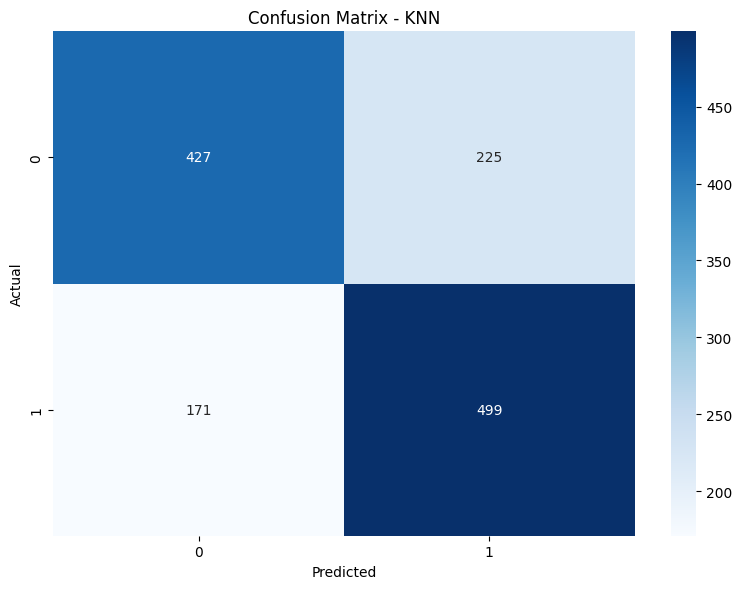

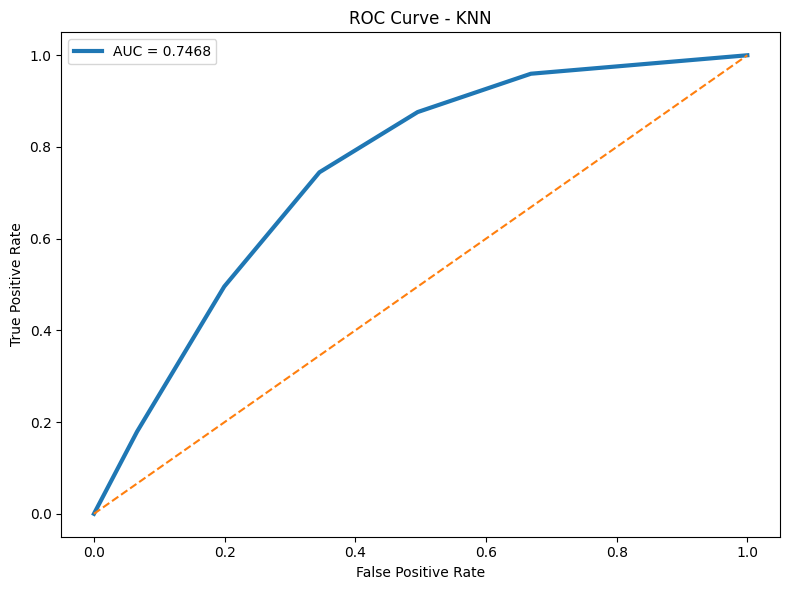



SVM

Cross-Validation Scores : [0.7440, 0.7560, 0.7105, 0.7608, 0.7314, 0.7866, 0.7386, 0.7002, 0.7266, 0.7770]
Media                   : 0.7432
Desvio padrao           : 0.0262

Accuracy Score : 0.7300


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.61      0.69       652
           1       0.69      0.85      0.76       670

    accuracy                           0.73      1322
   macro avg       0.74      0.73      0.73      1322
weighted avg       0.74      0.73      0.73      1322



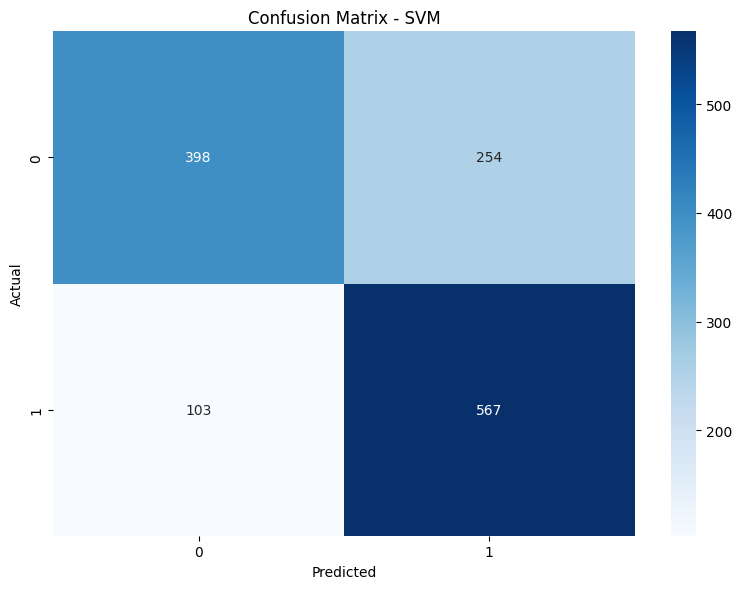

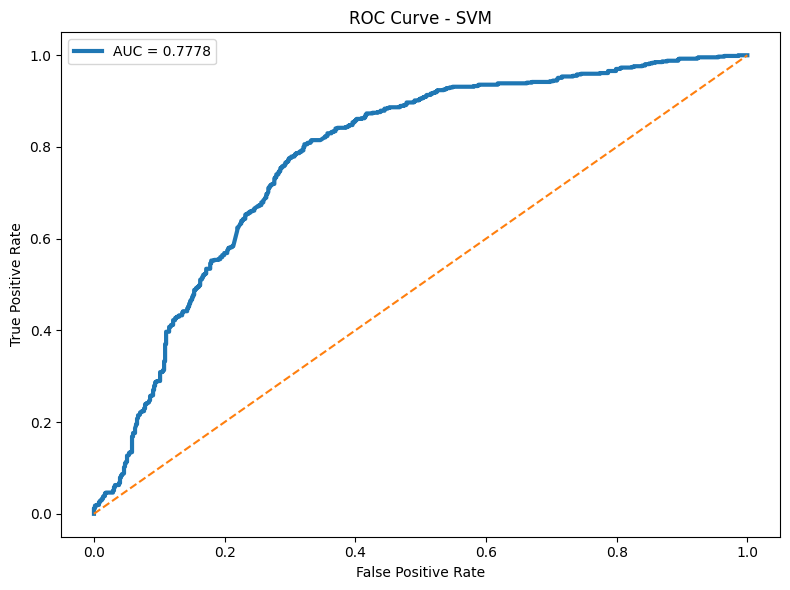



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.736762  0.795027
6                  SVM  0.729955  0.777843
4    Gradient Boosting  0.711044  0.783861
5                  KNN  0.700454  0.746789
1          Naive Bayes  0.690620  0.745337
3        Random Forest  0.685325  0.766862
2        Decision Tree  0.629349  0.631640


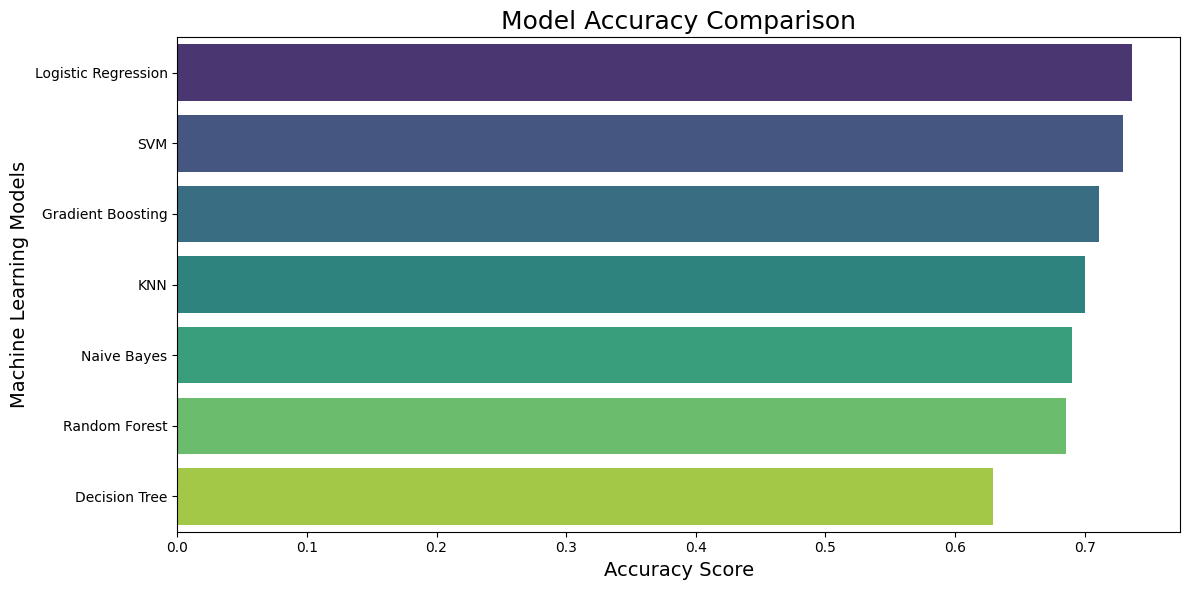

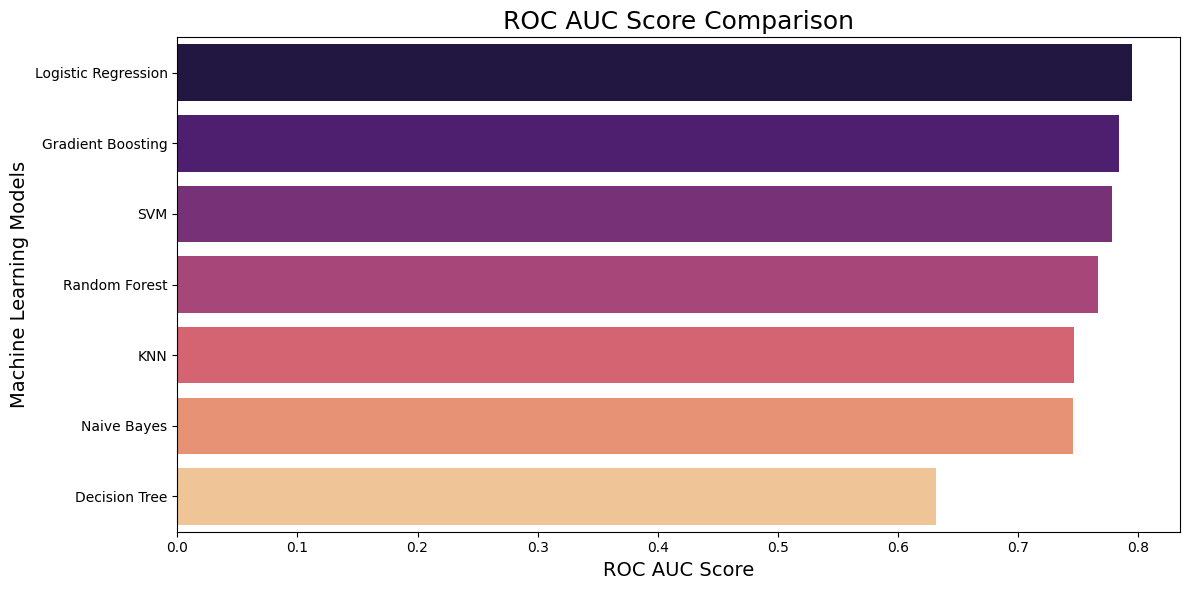



BEST MODEL
Best Model      : Logistic Regression
Best Accuracy   : 0.7368
Best ROC AUC    : 0.7950


RANDOM FOREST FEATURE IMPORTANCE
                            Feature  Importance
6      num__qtdeDiasUltimaTransacao    0.069179
22                 num__qtdeDiasD14    0.056269
7    num__qtdeDiasPrimeiraTransacao    0.055348
31             num__propAvgQtdeDias    0.051615
18                  num__qtdeDiasD7    0.050865
20             num__qtdePontosPosD7    0.047334
34        num__propAvgQtdePontosPos    0.044668
33          num__propAvgSaldoPontos    0.044235
24            num__qtdePontosPosD14    0.042973
30       num__propAvgQtdeTransacoes    0.042017
26                 num__qtdeDiasD28    0.041850
32  num__propAvgMediaTransacoesDias    0.039871
17            num__qtdeTransacoesD7    0.039649
28            num__qtdePontosPosD28    0.035787
3                  num__saldoPontos    0.031258
21           num__qtdeTransacoesD14    0.030082
4                num__qtdePontosPos    0.029591


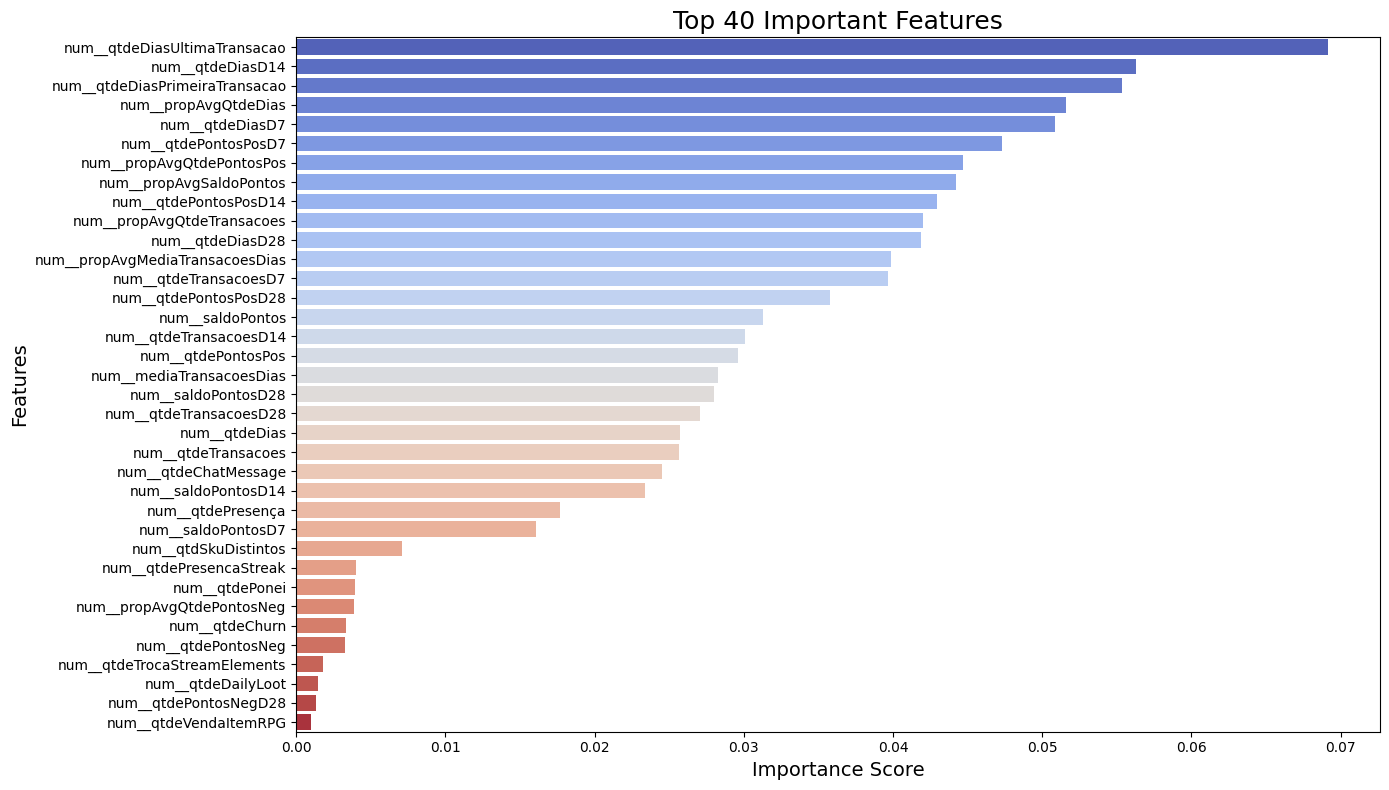



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [21]:
# ============================================================
# 
# ============================================================
# PCA ajuda modelos baseados em distancia/lineares (Logistic Regression,
# Naive Bayes, KNN, SVM) mas nao agrega para modelos baseados em arvore
# (Decision Tree, Random Forest, Gradient Boosting) -- alem de destruir
# a interpretabilidade nativa de feature importance desses ultimos.

use_pca = {
    "Logistic Regression": True,
    "Naive Bayes": True,
    "Decision Tree": False,
    "Random Forest": False,
    "Gradient Boosting": False,
    "KNN": True,
    "SVM": True,
}

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# ============================================================
# STORE RESULTS
# ============================================================

results = []
fitted_pipelines = {}  # guardamos os pipelines treinados para reaproveitar na feature importance

# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================


for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(model_name.upper())
    print("="*80)

    # Monta o pipeline (com ou sem PCA, dependendo do modelo)
    steps = [('preprocessor', preprocessor)]
    if use_pca.get(model_name, True):
        steps.append(('pca', PCA(n_components=0.95, random_state=42)))
    steps.append(('model', model))

    pipeline = Pipeline(steps=steps)

    # Cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=10)

    scores_str = ", ".join([f"{s:.4f}" for s in scores])
    print(f"\nCross-Validation Scores : [{scores_str}]")
    print(f"Media                   : {scores.mean():.4f}")
    print(f"Desvio padrao           : {scores.std():.4f}")

    # Train model
    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Prediction probabilities
    y_prob = pipeline.predict_proba(X_test)

    # ==============================================================
    # ACCURACY
    # ==============================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ==============================================================
    # CLASSIFICATION REPORT
    # ==============================================================

    print("\n")
    print("CLASSIFICATION REPORT")
    print("-"*60)

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    if len(np.unique(y)) == 2:

        auc_score = roc_auc_score(y_test, y_prob[:,1])

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob[:,1]
        )

        plt.figure(figsize=(8,6))

        plt.plot(
            fpr,
            tpr,
            linewidth=3,
            label=f'AUC = {auc_score:.4f}'
        )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"ROC Curve - {model_name}")

        plt.legend()

        plt.show()

    else:

        auc_score = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )

        print(f"\nMulti-Class ROC AUC Score : {auc_score:.4f}")

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score

    })

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df.sort_values(by='Accuracy', ascending=False))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df.sort_values(by='Accuracy', ascending=False),
    hue='Model',
    legend=False,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Accuracy Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# VISUALIZE ROC AUC SCORES
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df.sort_values(by='ROC_AUC', ascending=False),
    hue='Model',
    legend=False,
    palette='magma'
)

plt.title("ROC AUC Score Comparison", fontsize=18)

plt.xlabel("ROC AUC Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model      : {best_model['Model']}")
print(f"Best Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Best ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================
# 
# 
# 
# 
# 

print("\n")
print("="*80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*80)

rf_pipeline = fitted_pipelines['Random Forest']

all_features = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(40)

print(feature_importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    legend=False,
    palette='coolwarm'
)

plt.title("Top 40 Important Features", fontsize=18)

plt.xlabel("Importance Score", fontsize=14)

plt.ylabel("Features", fontsize=14)

plt.show()

# ============================================================
# COMPLETED
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)


# Interpretabilidade do Modelo: SHAP e AME (Average Marginal Effects)

O ranking de "RANDOM FOREST FEATURE IMPORTANCE" calculado acima usa a importância por impureza (Gini/MSE), que tem um viés conhecido: tende a favorecer variáveis numéricas contínuas e de alta cardinalidade, mesmo quando elas não são de fato as mais relevantes para a decisão do modelo.

Para chegar a uma resposta mais robusta sobre **qual parâmetro é mais importante para o modelo de churn**, vamos combinar três abordagens complementares:

1. **SHAP (SHapley Additive exPlanations)** — nos modelos de árvore (Gradient Boosting e Random Forest), que não passam por PCA e por isso permitem atribuir importância diretamente às features de negócio originais.
2. **AME (Average Marginal Effects)** — no modelo de Regressão Logística (o melhor modelo em Accuracy e ROC-AUC), medindo o efeito médio de cada variável sobre a probabilidade prevista de churn.
3. **Síntese** — um ranking consolidado comparando os três métodos, para identificar a(s) variável(is) que aparece(m) como mais importante(s) de forma consistente (e não apenas por um viés de um único método).

> **Nota sobre PCA:** Logistic Regression, Naive Bayes, KNN e SVM usam PCA no pipeline (`use_pca=True`), o que destrói a interpretabilidade em nível de feature original — os componentes principais são combinações lineares de várias variáveis ao mesmo tempo. Por isso, para a AME da Regressão Logística, ajustamos um modelo Logit equivalente (mesmo pré-processamento de imputação + padronização) **sem PCA**, apenas para fins de interpretação — o modelo de PCA continua sendo o utilizado para a decisão/predição em produção.

## 1. SHAP — Modelos de Árvore (Gradient Boosting e Random Forest)

In [ ]:
# ============================================================
# SETUP - SHAP
# ============================================================
import shap

shap.initjs()


In [ ]:
# ============================================================
# SHAP - GRADIENT BOOSTING
# ============================================================
# Gradient Boosting nao usa PCA (use_pca['Gradient Boosting'] = False) e foi o
# segundo melhor modelo em ROC-AUC -> TreeExplainer explica diretamente as
# features de negocio originais (apos imputacao/escala, antes do PCA).

gb_pipeline = fitted_pipelines['Gradient Boosting']
gb_preprocessor = gb_pipeline.named_steps['preprocessor']
gb_model = gb_pipeline.named_steps['model']

feature_names_gb = gb_preprocessor.get_feature_names_out()

X_test_transformed_gb = gb_preprocessor.transform(X_test)
X_test_gb_df = pd.DataFrame(X_test_transformed_gb, columns=feature_names_gb, index=X_test.index)

explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_test_gb_df)

# Dependendo da versao do shap, para classificacao binaria o retorno pode ser
# um array (n_samples, n_features) referente a classe positiva, ou uma lista
# [shap_classe_0, shap_classe_1]. Tratamos os dois casos.
if isinstance(shap_values_gb, list):
    shap_values_gb_pos = shap_values_gb[1]
else:
    shap_values_gb_pos = shap_values_gb

print("Shape dos valores SHAP (Gradient Boosting):", np.array(shap_values_gb_pos).shape)


In [ ]:
# ============================================================
# SHAP - GRAFICOS (GRADIENT BOOSTING)
# ============================================================

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_gb_pos, X_test_gb_df, plot_type="bar", show=False)
plt.title("SHAP - Importancia Media |SHAP value| - Gradient Boosting", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_gb_pos, X_test_gb_df, show=False)
plt.title("SHAP - Distribuicao dos Impactos por Feature - Gradient Boosting", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# SHAP - RANKING (GRADIENT BOOSTING)
# ============================================================

shap_importance_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Mean|SHAP|': np.abs(shap_values_gb_pos).mean(axis=0)
}).sort_values(by='Mean|SHAP|', ascending=False).reset_index(drop=True)

print("="*80)
print("TOP 15 FEATURES POR SHAP - GRADIENT BOOSTING")
print("="*80)
print(shap_importance_gb.head(15).to_string(index=False))

top_feature_gb = shap_importance_gb.iloc[0]['Feature']

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature_gb, shap_values_gb_pos, X_test_gb_df, show=False)
plt.title(f"SHAP Dependence Plot - {top_feature_gb} (Gradient Boosting)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# SHAP - RANDOM FOREST (checagem cruzada)
# ============================================================
# Random Forest tambem nao usa PCA. Comparamos o SHAP dele com a importancia
# por impureza ja calculada (feature_importance_df), para ver se os dois
# metodos concordam sobre quais variaveis pesam mais NESSE modelo especifico.

rf_pipeline = fitted_pipelines['Random Forest']
rf_preprocessor = rf_pipeline.named_steps['preprocessor']
rf_model = rf_pipeline.named_steps['model']

feature_names_rf = rf_preprocessor.get_feature_names_out()
X_test_transformed_rf = rf_preprocessor.transform(X_test)
X_test_rf_df = pd.DataFrame(X_test_transformed_rf, columns=feature_names_rf, index=X_test.index)

explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_rf_df)

if isinstance(shap_values_rf, list):
    shap_values_rf_pos = shap_values_rf[1]
else:
    shap_values_rf_pos = shap_values_rf
    # Alguns retornos vem com shape (n_samples, n_features, n_classes)
    if shap_values_rf_pos.ndim == 3:
        shap_values_rf_pos = shap_values_rf_pos[:, :, 1]

shap_importance_rf = pd.DataFrame({
    'Feature': feature_names_rf,
    'Mean|SHAP|': np.abs(shap_values_rf_pos).mean(axis=0)
}).sort_values(by='Mean|SHAP|', ascending=False).reset_index(drop=True)

print("="*80)
print("TOP 15 FEATURES POR SHAP - RANDOM FOREST")
print("="*80)
print(shap_importance_rf.head(15).to_string(index=False))

print("\nComparacao com a importancia por impureza (ja calculada acima) do mesmo modelo:")
comparacao_rf = feature_importance_df.merge(
    shap_importance_rf, on='Feature', how='inner'
).sort_values(by='Mean|SHAP|', ascending=False)
print(comparacao_rf.head(15).to_string(index=False))


## 2. AME (Average Marginal Effects) — Regressão Logística

In [ ]:
# ============================================================
# AME - PREPROCESSAMENTO SEM PCA (mantem as features originais interpretaveis)
# ============================================================
import statsmodels.api as sm
from sklearn.base import clone

# Usamos um clone do preprocessador original (imputacao + StandardScaler / OneHot)
# para nao interferir nos pipelines ja treinados em fitted_pipelines.
preprocessor_ame = clone(preprocessor)

X_train_ame = preprocessor_ame.fit_transform(X_train, y_train)
X_test_ame = preprocessor_ame.transform(X_test)

feature_names_ame = preprocessor_ame.get_feature_names_out()

X_train_ame_df = pd.DataFrame(X_train_ame, columns=feature_names_ame, index=X_train.index).astype(float)
X_test_ame_df = pd.DataFrame(X_test_ame, columns=feature_names_ame, index=X_test.index).astype(float)

X_train_ame_sm = sm.add_constant(X_train_ame_df)

print("Shape usado no Logit (statsmodels):", X_train_ame_sm.shape)


In [ ]:
# ============================================================
# AME - AJUSTE DO MODELO LOGIT (statsmodels)
# ============================================================
# Com 36 variaveis (varias correlacionadas, como visto no mapa de calor),
# a maxima verossimilhanca pode nao convergir bem. Se isso acontecer,
# caimos para uma versao regularizada (L1) do Logit.

try:
    logit_result = sm.Logit(y_train.values, X_train_ame_sm).fit(disp=0, maxiter=200)
    ame_method = "MLE (sm.Logit.fit)"
    tem_cov_params = True
except Exception as e:
    print(f"MLE nao convergiu ({e}). Usando regularizacao L1 (fit_regularized).")
    logit_result = sm.Logit(y_train.values, X_train_ame_sm).fit_regularized(alpha=1.0, disp=0)
    ame_method = "Regularizado L1 (fit_regularized)"
    tem_cov_params = False

print(f"\nMetodo utilizado: {ame_method}")
print(logit_result.summary())


In [ ]:
# ============================================================
# AME - CALCULO DOS EFEITOS MARGINAIS MEDIOS
# ============================================================

try:
    if not tem_cov_params:
        raise RuntimeError("Modelo regularizado nao tem matriz de covariancia -> get_margeff indisponivel")
    margeff = logit_result.get_margeff(at='overall', method='dydx')
    ame_df = pd.DataFrame({
        'Feature': X_train_ame_sm.columns[1:],
        'AME': margeff.margeff,
        'Std Err': margeff.margeff_se,
        'p-value': margeff.pvalues
    })
except Exception as e:
    # Fallback: AME por diferenca finita diretamente sobre a probabilidade prevista
    print(f"get_margeff indisponivel ({e}). Calculando AME por diferenca finita (dy/dx numerico).")
    eps = 1e-4
    base_probs = logit_result.predict(X_train_ame_sm)
    ame_list = []
    for col in X_train_ame_df.columns:
        X_plus = X_train_ame_sm.copy()
        X_plus[col] = X_plus[col] + eps
        probs_plus = logit_result.predict(X_plus)
        ame_list.append((probs_plus - base_probs).mean() / eps)
    ame_df = pd.DataFrame({'Feature': X_train_ame_df.columns, 'AME': ame_list})

ame_df['AME_abs'] = ame_df['AME'].abs()
ame_df = ame_df.sort_values(by='AME_abs', ascending=False).reset_index(drop=True)

print("="*80)
print("TOP 15 FEATURES POR AME (efeito medio na probabilidade PREVISTA de churn)")
print("="*80)
print(ame_df.head(15).to_string(index=False))


In [ ]:
# ============================================================
# AME - GRAFICO
# ============================================================

top15_ame = ame_df.head(15).sort_values(by='AME')
cores = ['#d62728' if v > 0 else '#1f77b4' for v in top15_ame['AME']]

plt.figure(figsize=(12, 8))
plt.barh(top15_ame['Feature'], top15_ame['AME'], color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Top 15 Features - Average Marginal Effect (AME) na Probabilidade de Churn", fontsize=16)
plt.xlabel("Efeito medio na probabilidade prevista de churn", fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretacao:")
print("- Barras vermelhas (AME > 0): aumento na variavel aumenta, em media, a probabilidade prevista de churn.")
print("- Barras azuis  (AME < 0): aumento na variavel reduz, em media, a probabilidade prevista de churn.")


## 3. Síntese — Ranking Consolidado (RF Importance + SHAP + AME)

In [ ]:
# ============================================================
# RANKING CONSOLIDADO - COMPARANDO OS TRES METODOS
# ============================================================
# Cada metodo enxerga "importancia" de um jeito diferente (impureza no split,
# contribuicao Shapley para a predicao, efeito marginal na probabilidade).
# Se uma mesma variavel aparece no topo nos tres, isso e evidencia forte de
# que ela e, de fato, o principal direcionador do churn -- e nao apenas um
# artefato de um metodo/modelo especifico.

def normalizar_nome(feat):
    return feat.replace('num__', '').replace('cat__', '')

rf_rank = feature_importance_df.copy()
rf_rank['Feature_norm'] = rf_rank['Feature'].apply(normalizar_nome)
rf_rank['Rank_RF_Impureza'] = rf_rank['Importance'].rank(ascending=False)

shap_rank = shap_importance_gb.copy()
shap_rank['Feature_norm'] = shap_rank['Feature'].apply(normalizar_nome)
shap_rank['Rank_SHAP_GB'] = shap_rank['Mean|SHAP|'].rank(ascending=False)

ame_rank = ame_df.copy()
ame_rank['Feature_norm'] = ame_rank['Feature'].apply(normalizar_nome)
ame_rank['Rank_AME_LogReg'] = ame_rank['AME_abs'].rank(ascending=False)

consolidado = (
    rf_rank[['Feature_norm', 'Rank_RF_Impureza']]
    .merge(shap_rank[['Feature_norm', 'Rank_SHAP_GB']], on='Feature_norm', how='outer')
    .merge(ame_rank[['Feature_norm', 'Rank_AME_LogReg']], on='Feature_norm', how='outer')
)

consolidado['Rank_Medio'] = consolidado[
    ['Rank_RF_Impureza', 'Rank_SHAP_GB', 'Rank_AME_LogReg']
].mean(axis=1)

consolidado = consolidado.sort_values(by='Rank_Medio').reset_index(drop=True)

print("="*80)
print("RANKING CONSOLIDADO DE IMPORTANCIA - TOP 15")
print("="*80)
print(consolidado.head(15).to_string(index=False))

feature_mais_importante = consolidado.iloc[0]['Feature_norm']
print("\n" + "="*80)
print(f">>> PARAMETRO MAIS IMPORTANTE PARA O MODELO DE CHURN (consenso RF + SHAP + AME): {feature_mais_importante}")
print("="*80)


### Leitura dos resultados e cuidados antes de decidir

- **Convergência dos métodos**: se a mesma variável aparecer no topo do `Rank_RF_Impureza`, `Rank_SHAP_GB` e `Rank_AME_LogReg`, é um sinal forte de que ela realmente é o principal direcionador de churn — não um artefato de um único modelo. Se os métodos discordarem muito, vale investigar se algum modelo está capturando um padrão espúrio (ou colinearidade, como já sinalizado no mapa de calor de correlação).
- **Checagem de vazamento**: antes de tomar a variável do topo do ranking como *a* resposta de negócio, confirme que ela não é um proxy do próprio evento de churn (como já foi investigado para `qtdeChurn` na célula de checagem de vazamento, acima). Nomes como `qtdeDiasUltimaTransacao` fazem sentido causal (cliente inativo há mais tempo → maior chance de churn), mas vale sempre essa checagem para qualquer variável que assumir o topo.
- **SHAP explica o modelo, não a realidade**: os valores SHAP mostram o que o *Gradient Boosting* aprendeu como relevante — é uma leitura de como o modelo decide, e não uma prova de causalidade sobre o comportamento real do cliente.
- **AME assume uma forma funcional (logit linear nos preditores)**: o efeito marginal médio da Regressão Logística pressupõe que a relação entre cada variável e o log-odds de churn é aproximadamente linear (após padronização). Se essa relação for muito não-linear, o AME pode subestimar a importância real da variável — por isso ele é usado aqui em conjunto com o SHAP (que captura não-linearidades), e não isoladamente.